# Refining data

In this notebook I will be refining certain things in the datasets so I am able to work out some of the following.

Personel Movement - QB, WR...
DOwn and distance
Offensive and defensice pre snap formations
Team tendecies
What percentage of plays are run/pass
Distance between defenders and WRs 
How often each defense sets up in what
What kind of throws each QB uses the most
What route the WR prefer

In [39]:
#setup - load data and import shared plotting helpers
import sys
sys.path.append('../src')

import pandas as pd
from data_plotting.plotting_helper import plot_play, get_random_play

players = pd.read_csv('/Users/seanlee/Desktop/Github_repositories/Practice-repo/data/players.csv')
tracking_week1 = pd.read_csv('/Users/seanlee/Desktop/Github_repositories/Practice-repo/data/tracking_week_1.csv')

game_id, play_id, one_play = get_random_play(tracking_week1)

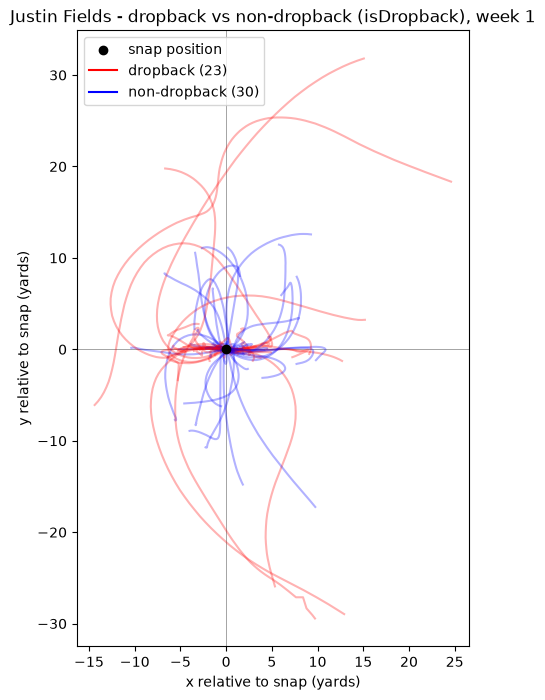

skipped 0 of 53 plays


In [40]:
#overlay a specific QB's movement across all his plays in week 1, color-coded by plays.csv's isDropback
import matplotlib.pyplot as plt

plays = pd.read_csv('/Users/seanlee/Desktop/Github_repositories/Practice-repo/data/plays.csv')

qb_name = 'Justin Fields'

qb_id = players.loc[players['displayName'] == qb_name, 'nflId'].iloc[0]
qb_tracking = tracking_week1[tracking_week1['nflId'] == qb_id]

qb_plays = qb_tracking[['gameId', 'playId']].drop_duplicates()

fig, ax = plt.subplots(figsize=(8, 8))
ax.axhline(0, color='grey', linewidth=0.5)
ax.axvline(0, color='grey', linewidth=0.5)

dropback_count = 0
non_dropback_count = 0
skipped = 0

for _, row in qb_plays.iterrows():
    g_id, p_id = row['gameId'], row['playId']
    play_df = qb_tracking[(qb_tracking['gameId'] == g_id) & (qb_tracking['playId'] == p_id)]

    snap_row = play_df[play_df['event'] == 'ball_snap']
    if snap_row.empty:
        skipped += 1
        continue

    snap_x = snap_row['x'].iloc[0]
    snap_y = snap_row['y'].iloc[0]

    play_info = plays[(plays['gameId'] == g_id) & (plays['playId'] == p_id)]
    if play_info.empty:
        skipped += 1
        continue

    if play_info['isDropback'].iloc[0]:
        dropback_count += 1
        color = 'red'
    else:
        non_dropback_count += 1
        color = 'blue'

    ax.plot(play_df['x'] - snap_x, play_df['y'] - snap_y, color=color, alpha=0.3)

ax.scatter(0, 0, color='black', zorder=5, label='snap position')
ax.plot([], [], color='red', label=f'dropback ({dropback_count})')
ax.plot([], [], color='blue', label=f'non-dropback ({non_dropback_count})')
ax.legend()
ax.set_aspect('equal')
ax.set_title(f"{qb_name} - dropback vs non-dropback (isDropback), week 1")
ax.set_xlabel('x relative to snap (yards)')
ax.set_ylabel('y relative to snap (yards)')
plt.show()

print(f"skipped {skipped} of {len(qb_plays)} plays")

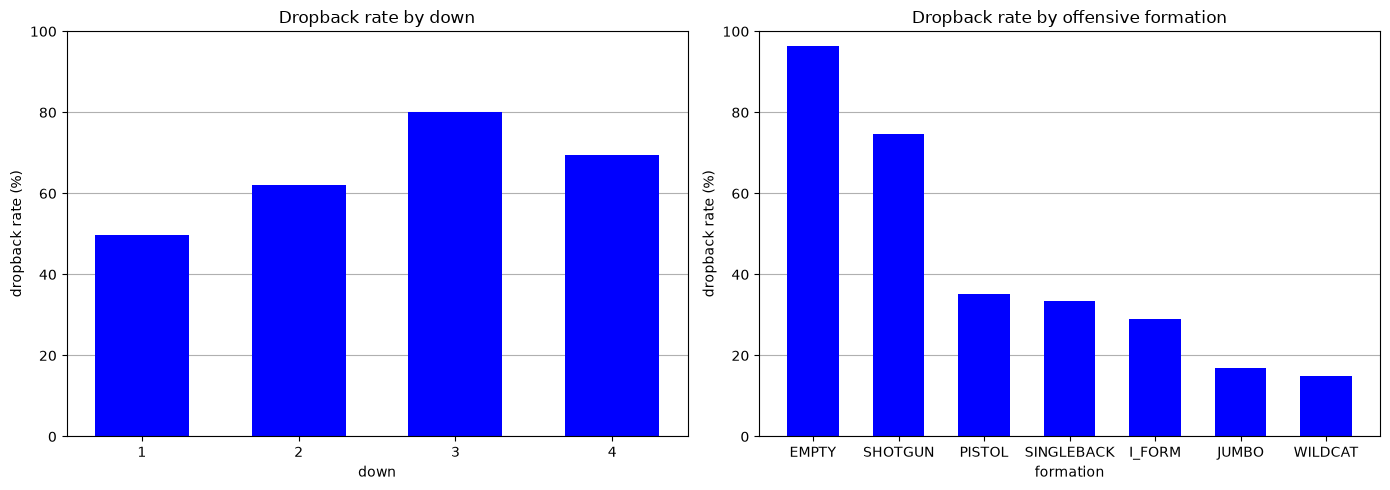

In [41]:
#dropback rate by down and by offensive formation, across week 1
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bar_color = 'blue'

def style_bar_axis(ax, values):
    ax.set_ylim(0, 100)
    ax.set_ylabel('dropback rate (%)')
    ax.grid(axis='y', linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)

# by down
by_down = plays.groupby('down')['isDropback'].mean() * 100
ax = axes[0]
bars = ax.bar(by_down.index.astype(str), by_down.values, color=bar_color, width=0.6)
ax.set_title('Dropback rate by down')
ax.set_xlabel('down')
style_bar_axis(ax, by_down.values)


# by offensive formation
by_formation = (plays.groupby('offenseFormation')['isDropback'].mean() * 100).sort_values(ascending=False)
ax = axes[1]
bars = ax.bar(by_formation.index, by_formation.values, color=bar_color, width=0.6)
ax.set_title('Dropback rate by offensive formation')
ax.set_xlabel('formation')
style_bar_axis(ax, by_formation.values)

plt.tight_layout()
plt.show()

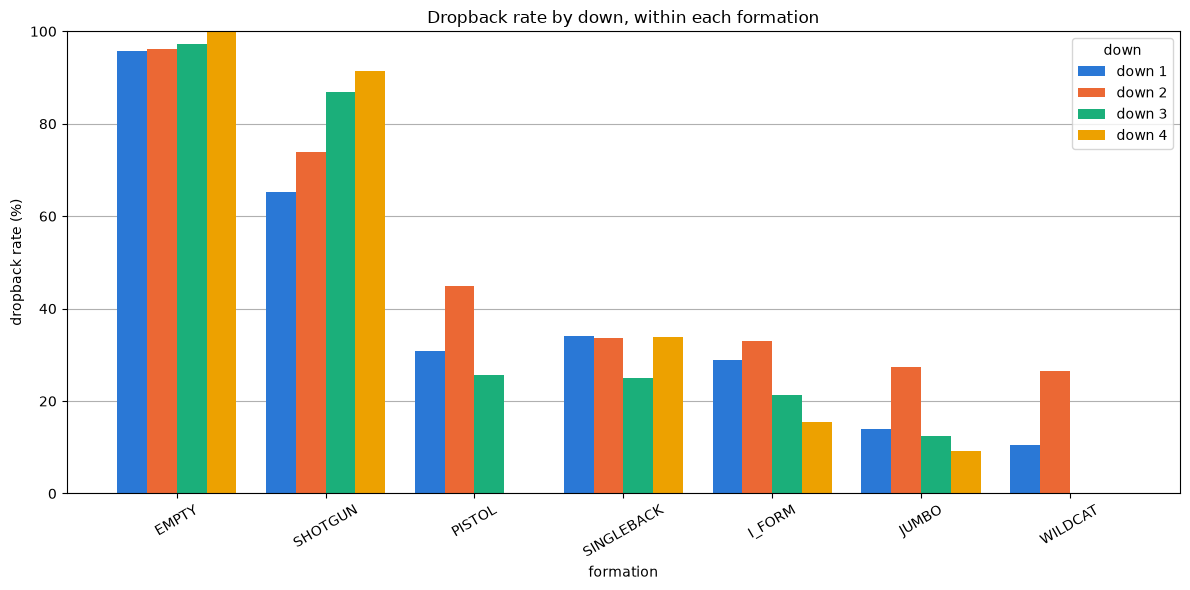

In [42]:
#dropback rate by down, within each offensive formation
import numpy as np

down_colors = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100']  # categorical slots for down 1-4
downs = [1, 2, 3, 4]
formation_order = by_formation.index.tolist()  # same order as the formation chart above

rate_table = plays.groupby(['offenseFormation', 'down'])['isDropback'].mean().mul(100).unstack('down')
rate_table = rate_table.reindex(formation_order)

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(formation_order))
bar_width = 0.8 / len(downs)

for i, down in enumerate(downs):
    offsets = x - 0.4 + bar_width * (i + 0.5)
    ax.bar(offsets, rate_table[down].values, width=bar_width, color=down_colors[i], label=f'down {down}')

ax.set_xticks(x)
ax.set_xticklabels(formation_order, rotation=30)
ax.set_title('Dropback rate by down, within each formation')
ax.set_xlabel('formation')
style_bar_axis(ax, None)
ax.legend(title='down')

plt.tight_layout()
plt.show()
